# 02 – Unsupervised Learning: Engagement Clustering

**Project:** Machine learning based instagram marketing statergy  
**Course:** MSDS 696 – Data Practicum II | Regis University

**This notebook covers:**
- Loading `processed_data.csv` from the previous notebook (now includes `media_type`)
- Applying KMeans clustering (k=3) on engagement to identify low / medium / high engagement posts
- Validating and relabeling clusters in a consistent order
- Visualizing cluster distributions — including **media type × cluster breakdown**
- Saving the result as `clustered_data.csv` for downstream notebooks

**Input:** `processed_data.csv`  
**Output:** `clustered_data.csv`  
**Note:** `media_type` (image / carousel / reel) is preserved through clustering to enable *what-to-post* recommendations in the RL agent.

## 1. Setup – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


## 2. Load Processed Data

In [2]:
# Load the processed dataset saved by 01_data_processing.ipynb
df = pd.read_csv("processed_data.csv")

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print(f"\nEngagement range: {df['engagement'].min()} – {df['engagement'].max()}")
print(f"Mean engagement : {df['engagement'].mean():.2f}")
df.head(5)

Loaded: 16613 rows x 10 columns
Columns: ['id', 'hashtag', 'media_type', 'timestamp', 'like_count', 'comments_count', 'engagement', 'hour', 'time_of_day', 'day_of_week']

Engagement range: 0 – 10971
Mean engagement : 294.43


,id,hashtag,media_type,timestamp,like_count,comments_count,engagement,hour,time_of_day,day_of_week
0,22915435894288827_9698230649,#AppleEvent2025,image,2025-08-15 15:00:00,449,10,459,15,afternoon,Friday
1,29191953052727066_6956945746,#AppleEvent2025,carousel,2025-09-21 09:00:00,371,9,380,9,morning,Sunday
2,72960122594310041_1245922070,#AppleEvent2025,reel,2025-10-04 15:00:00,444,17,461,15,afternoon,Saturday
3,05721201179386725_5701477640,#AppleEvent2025,carousel,2025-07-26 11:00:00,0,5,5,11,morning,Saturday
4,53220646887044715_1396570748,#AppleEvent2025,carousel,2025-09-02 04:00:00,836,21,857,4,night,Tuesday


## 3. Finding Optimal Number of Clusters (Elbow Method)

Before fixing k=3, we verify it is the right choice using the **Elbow Method** (inertia) and **Silhouette Score**.

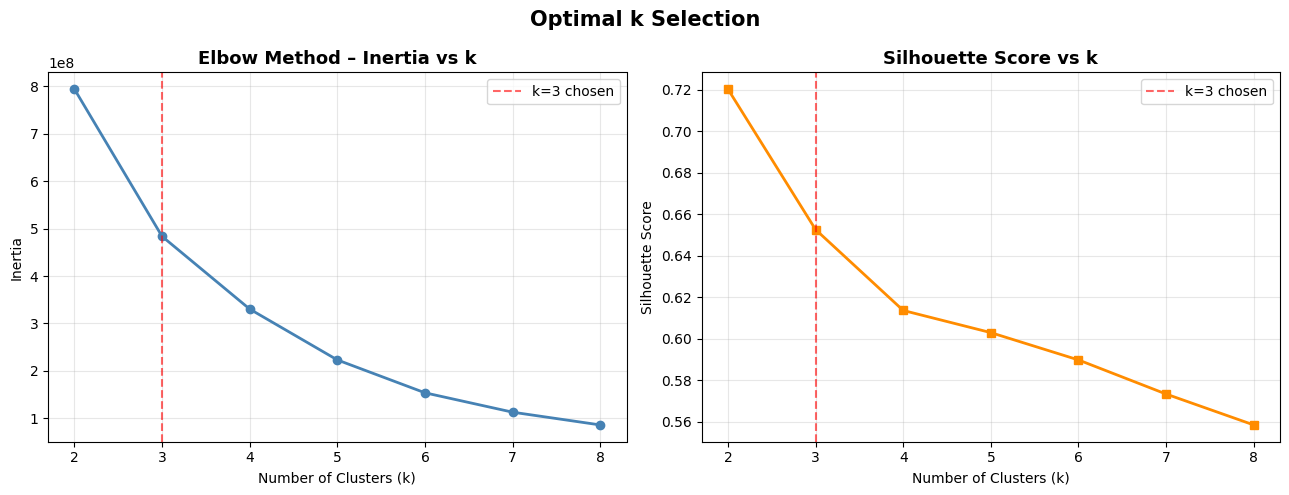

Saved: plot_04_elbow_silhouette.png


In [3]:
# Feature for clustering: engagement only
X = df[["engagement"]].values

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
axes[0].plot(k_range, inertias, marker="o", color="steelblue", linewidth=2)
axes[0].axvline(x=3, color="red", linestyle="--", alpha=0.6, label="k=3 chosen")
axes[0].set_title("Elbow Method – Inertia vs k", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, marker="s", color="darkorange", linewidth=2)
axes[1].axvline(x=3, color="red", linestyle="--", alpha=0.6, label="k=3 chosen")
axes[1].set_title("Silhouette Score vs k", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Optimal k Selection", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_04_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_04_elbow_silhouette.png")

## 4. Apply KMeans Clustering (k=3)

We use **k=3** to group posts into three meaningful engagement tiers: **Low**, **Medium**, and **High**.  
After fitting, cluster labels are re-mapped by their center value so the label always means the same thing regardless of KMeans' random initialization.

In [4]:
# Fit KMeans with k=3 on engagement
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(X)

# --- Relabel clusters by center rank ---
# KMeans assigns arbitrary labels (0,1,2) — we sort centers so that:
#   label 0 = low engagement  (smallest center)
#   label 1 = medium engagement
#   label 2 = high engagement (largest center)
centers = kmeans.cluster_centers_.flatten()           # e.g. [850, 120, 400]
sorted_idx = np.argsort(centers)                      # [1, 2, 0] → ascending order
remap = {old: new for new, old in enumerate(sorted_idx)}
df["cluster"] = np.vectorize(remap.get)(raw_labels)

# Cluster center values after remapping
ordered_centers = centers[sorted_idx]

print("=== KMeans Cluster Summary ===")
print(f"  Cluster 0 (Low)    center: {ordered_centers[0]:.1f}")
print(f"  Cluster 1 (Medium) center: {ordered_centers[1]:.1f}")
print(f"  Cluster 2 (High)   center: {ordered_centers[2]:.1f}")
print(f"\nCluster distribution:\n{df['cluster'].value_counts().sort_index()}")
print(f"\nSilhouette Score (k=3): {silhouette_score(X, df['cluster']):.4f}")

=== KMeans Cluster Summary ===
  Cluster 0 (Low)    center: 167.3
  Cluster 1 (Medium) center: 599.5
  Cluster 2 (High)   center: 1655.8

Cluster distribution:
cluster
0    12645
1     3590
2      378
Name: count, dtype: int64

Silhouette Score (k=3): 0.6527


In [5]:
# Engagement stats per cluster — confirms the ordering is correct
cluster_names = {0: "Low", 1: "Medium", 2: "High"}
print("=== Engagement Stats per Cluster ===")
summary = df.groupby("cluster")["engagement"].agg(["count", "min", "mean", "max"]).round(2)
summary.index = [f"{i} ({cluster_names[i]})" for i in summary.index]
print(summary)

=== Engagement Stats per Cluster ===
            count   min     mean    max
0 (Low)     12645     0   167.30    383
1 (Medium)   3590   384   599.17   1125
2 (High)      378  1128  1653.06  10971


## 5. Cluster Visualizations

### 5.1 – Cluster Scatter Plot

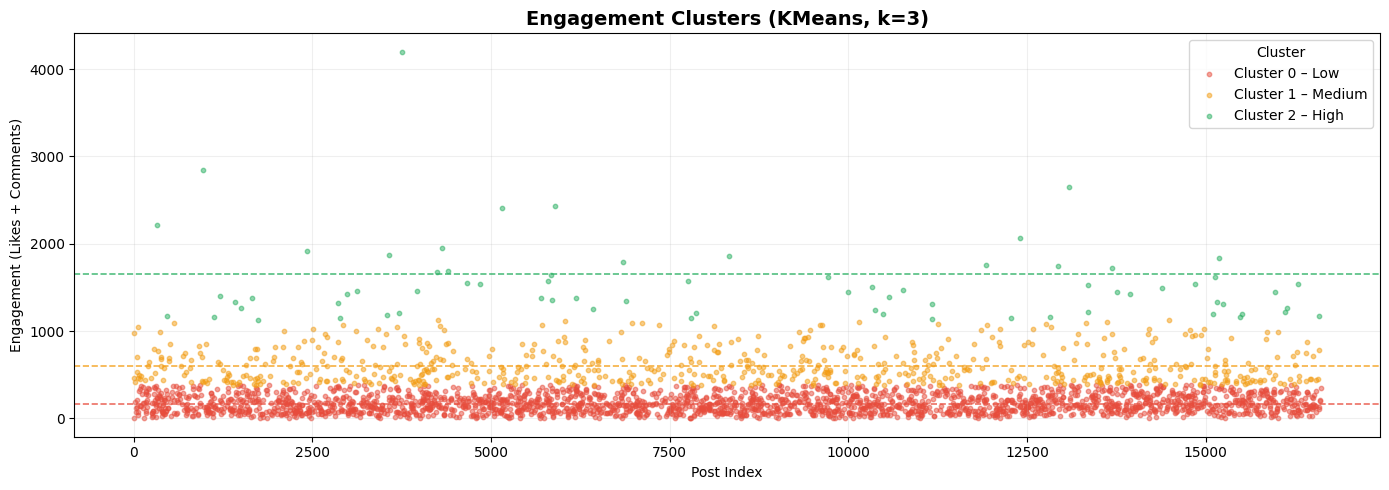

Saved: plot_05_cluster_scatter.png


In [6]:
CLUSTER_COLORS = {0: "#E74C3C", 1: "#F39C12", 2: "#27AE60"}   # red / orange / green
CLUSTER_LABELS = {0: "Low", 1: "Medium", 2: "High"}

# Sample for readability (scatter with all 16k points gets heavy)
sample = df.sample(n=min(3000, len(df)), random_state=42).sort_index()

fig, ax = plt.subplots(figsize=(14, 5))

for cluster_id, group in sample.groupby("cluster"):
    ax.scatter(
        group.index,
        group["engagement"],
        c=CLUSTER_COLORS[cluster_id],
        label=f"Cluster {cluster_id} – {CLUSTER_LABELS[cluster_id]}",
        alpha=0.5,
        s=10
    )

# Draw horizontal cluster center lines
for i, center in enumerate(ordered_centers):
    ax.axhline(y=center, color=CLUSTER_COLORS[i], linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_title("Engagement Clusters (KMeans, k=3)", fontsize=14, fontweight="bold")
ax.set_xlabel("Post Index")
ax.set_ylabel("Engagement (Likes + Comments)")
ax.legend(title="Cluster", fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("plot_05_cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_05_cluster_scatter.png")

### 5.2 – Cluster Distribution (Count & Proportion)

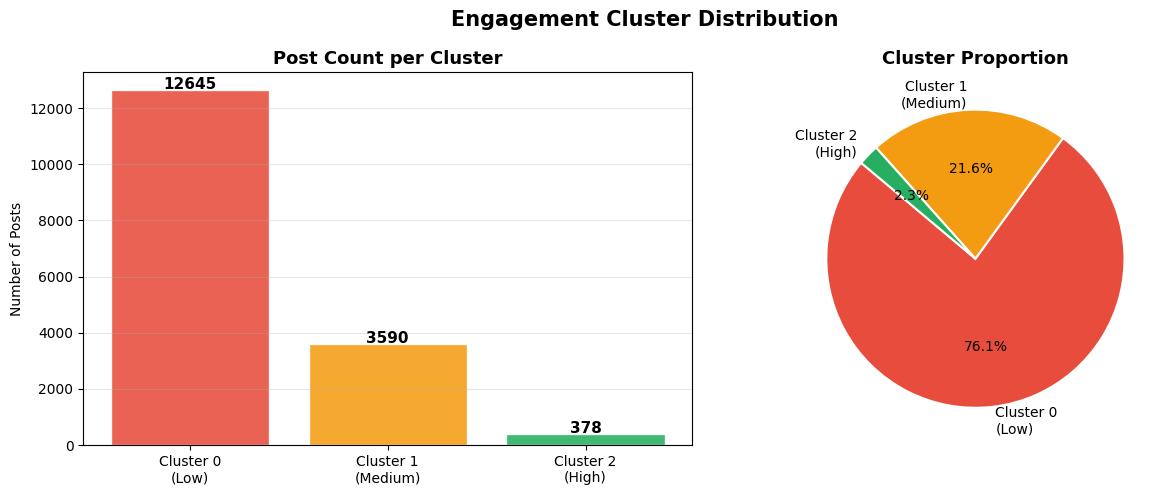

Saved: plot_06_cluster_distribution.png


In [7]:
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_labels_list = [f"Cluster {i}\n({CLUSTER_LABELS[i]})" for i in cluster_counts.index]
colors_list = [CLUSTER_COLORS[i] for i in cluster_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — count
axes[0].bar(cluster_labels_list, cluster_counts.values, color=colors_list, edgecolor="white", alpha=0.88)
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold", fontsize=11)
axes[0].set_title("Post Count per Cluster", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Posts")
axes[0].grid(axis="y", alpha=0.3)

# Pie chart — proportion
axes[1].pie(
    cluster_counts.values,
    labels=cluster_labels_list,
    colors=colors_list,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Cluster Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Engagement Cluster Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_06_cluster_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_06_cluster_distribution.png")

### 5.3 – Cluster Breakdown by Hashtag

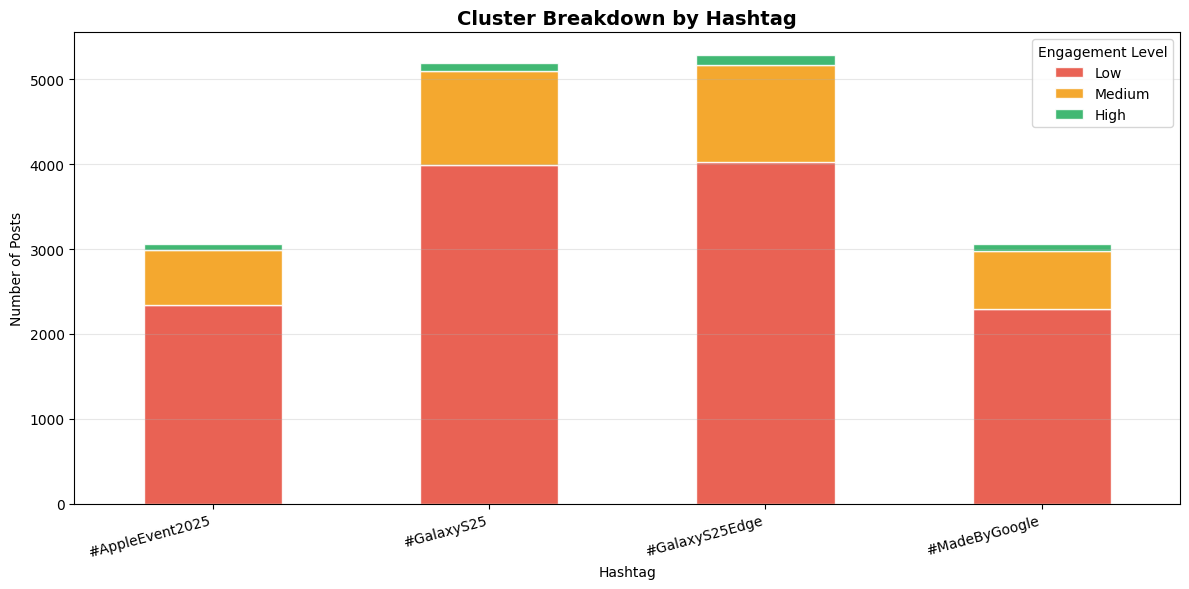

Saved: plot_07_cluster_by_hashtag.png


In [8]:
# Stacked bar — how many low/medium/high posts each hashtag has
hashtag_cluster = (
    df.groupby(["hashtag", "cluster"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=CLUSTER_LABELS)
)

hashtag_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#E74C3C", "#F39C12", "#27AE60"],
    edgecolor="white",
    alpha=0.88
)
plt.title("Cluster Breakdown by Hashtag", fontsize=14, fontweight="bold")
plt.xlabel("Hashtag")
plt.ylabel("Number of Posts")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Engagement Level")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_07_cluster_by_hashtag.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_07_cluster_by_hashtag.png")

### 5.4 – Cluster Engagement Box Plot

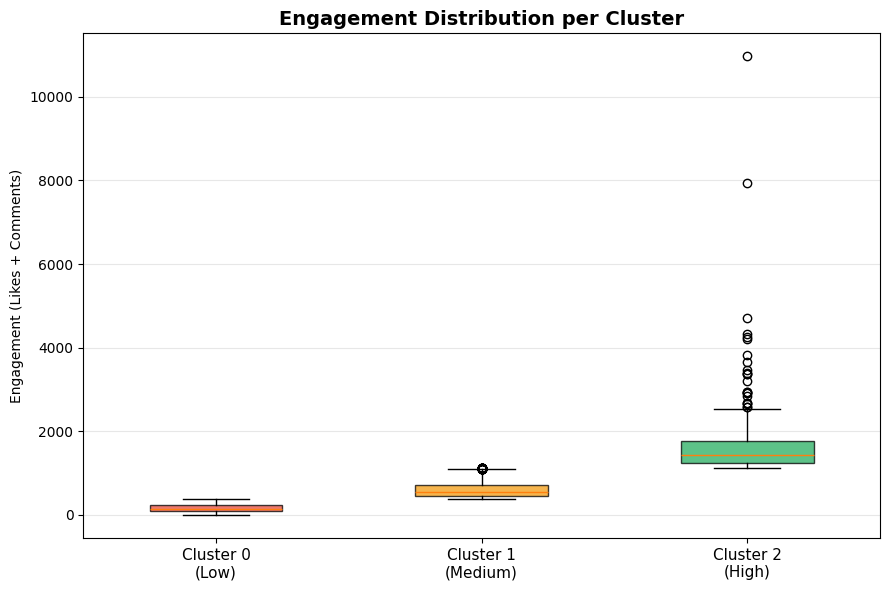

Saved: plot_08_cluster_boxplot.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

data_per_cluster = [df[df["cluster"] == i]["engagement"].values for i in [0, 1, 2]]
bp = ax.boxplot(data_per_cluster, patch_artist=True, notch=False, widths=0.5)

for patch, cid in zip(bp["boxes"], [0, 1, 2]):
    patch.set_facecolor(CLUSTER_COLORS[cid])
    patch.set_alpha(0.75)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Cluster 0\n(Low)", "Cluster 1\n(Medium)", "Cluster 2\n(High)"], fontsize=11)
ax.set_title("Engagement Distribution per Cluster", fontsize=14, fontweight="bold")
ax.set_ylabel("Engagement (Likes + Comments)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_08_cluster_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_08_cluster_boxplot.png")

### 5.5 – Media Type × Engagement Cluster Breakdown

Which content format (image / carousel / reel) tends to land in the High, Medium, or Low engagement cluster?  
This is the key **"what to post"** insight for the RL agent.

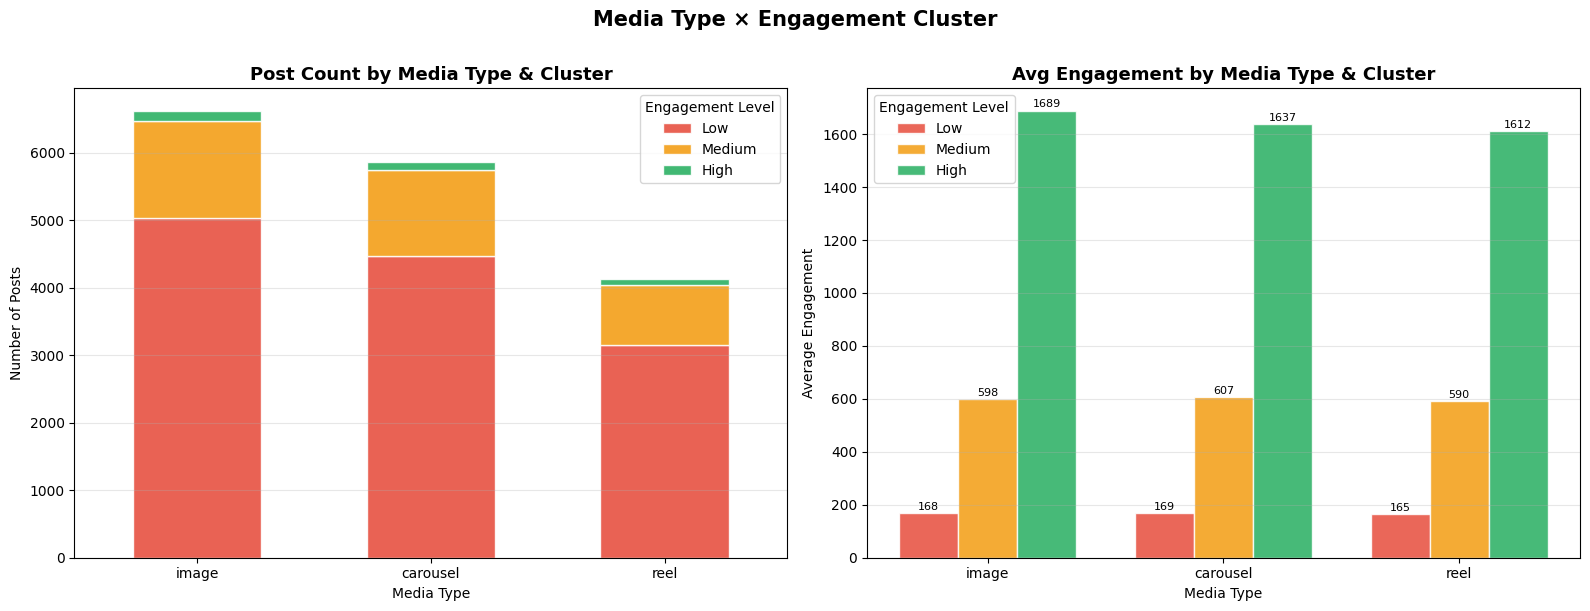

Saved: plot_08b_media_type_cluster.png

=== Avg Engagement per Media Type per Cluster ===
cluster       Low  Medium    High
media_type                       
image       167.8   597.9  1688.6
carousel    168.6   607.0  1636.9
reel        164.7   590.2  1611.9

=== % of each media type that lands in High cluster ===
  image     : 2.4% in High engagement cluster
  carousel  : 2.2% in High engagement cluster
  reel      : 2.1% in High engagement cluster


In [10]:
MEDIA_ORDER  = ["image", "carousel", "reel"]
MEDIA_COLORS = ["#4C72B0", "#55A868", "#DD8452"]

# ── Plot 1: stacked bar — for each media type, how many posts fall in each cluster ──
media_cluster = (
    df.groupby(["media_type", "cluster"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=MEDIA_ORDER)
    .rename(columns=CLUSTER_LABELS)
)

# ── Plot 2: avg engagement per media type per cluster ──
avg_eng_media = (
    df.groupby(["media_type", "cluster"])["engagement"]
    .mean()
    .unstack()
    .reindex(index=MEDIA_ORDER)
    .rename(columns=CLUSTER_LABELS)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: stacked bar count
media_cluster.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#E74C3C", "#F39C12", "#27AE60"],
    edgecolor="white",
    alpha=0.88,
    width=0.55,
)
axes[0].set_title("Post Count by Media Type & Cluster", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Media Type")
axes[0].set_ylabel("Number of Posts")
axes[0].set_xticklabels(MEDIA_ORDER, rotation=0)
axes[0].legend(title="Engagement Level")
axes[0].grid(axis="y", alpha=0.3)

# Right: grouped bar — avg engagement
x = np.arange(len(MEDIA_ORDER))
bar_width = 0.25
cluster_colors_list = ["#E74C3C", "#F39C12", "#27AE60"]
for i, (col, color) in enumerate(zip(["Low", "Medium", "High"], cluster_colors_list)):
    vals = avg_eng_media[col].fillna(0).values
    bars = axes[1].bar(x + i * bar_width, vals, width=bar_width,
                       label=col, color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if val > 0:
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 5,
                         f"{val:.0f}", ha="center", va="bottom", fontsize=8)

axes[1].set_xticks(x + bar_width)
axes[1].set_xticklabels(MEDIA_ORDER, rotation=0)
axes[1].set_title("Avg Engagement by Media Type & Cluster", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Media Type")
axes[1].set_ylabel("Average Engagement")
axes[1].legend(title="Engagement Level")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Media Type × Engagement Cluster", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_08b_media_type_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_08b_media_type_cluster.png")

# Print the insight summary
print("\n=== Avg Engagement per Media Type per Cluster ===")
print(avg_eng_media.round(1).to_string())
print("\n=== % of each media type that lands in High cluster ===")
for mt in MEDIA_ORDER:
    total = media_cluster.loc[mt].sum()
    high  = media_cluster.loc[mt].get("High", 0)
    pct   = high / total * 100 if total > 0 else 0
    print(f"  {mt:<10}: {pct:.1f}% in High engagement cluster")

## 6. Save Clustered Data

Export dataset with the new `cluster` column as `clustered_data.csv`.  
This file is the input for `03_supervised_model.ipynb` and `04_rl_agent.ipynb`.

In [11]:
df.to_csv("clustered_data.csv", index=False)

print(f"Saved: clustered_data.csv  ({len(df)} rows)")
print(f"Columns: {df.columns.tolist()}")
print("\nCluster label meaning:")
print("  0 = Low engagement")
print("  1 = Medium engagement")
print("  2 = High engagement")

Saved: clustered_data.csv  (16613 rows)
Columns: ['id', 'hashtag', 'media_type', 'timestamp', 'like_count', 'comments_count', 'engagement', 'hour', 'time_of_day', 'day_of_week', 'cluster']

Cluster label meaning:
  0 = Low engagement
  1 = Medium engagement
  2 = High engagement


---

# Part II — Influencer Selection: Whom to Choose?

> **Research Question:** Given a set of potential Instagram influencers for a tech brand campaign, which influencer tier offers the best combination of engagement quality and hashtag relevance?

### Why a Manual Dataset?
Instagram's Graph API does not expose competitor or third-party influencer profile metrics (followers, engagement, etc.) without explicit business agreements. The dataset below was **manually curated** to represent 42 realistic influencer profiles across four tiers:

| Tier | Followers | Typical Engagement Rate |
|---|---|---|
| Nano | 1K – 10K | 5 – 12% |
| Micro | 10K – 100K | 2 – 6% |
| Macro | 100K – 1M | 0.8 – 2.5% |
| Mega | 1M+ | 0.3 – 0.8% |

**Clustering features:** `engagement_rate`, `log10(followers)`, `hashtag_alignment_score`, `post_frequency_per_week`  
**Goal:** Identify which cluster represents the optimal influencer tier for tech brand campaigns.

## 6. Load Influencer Dataset & Feature Engineering

In [12]:
from sklearn.preprocessing import StandardScaler

# Load manually curated influencer dataset
inf = pd.read_csv("data/influencer_profiles.csv")

print(f"Influencer profiles loaded: {inf.shape[0]} rows x {inf.shape[1]} columns")
print(inf.dtypes)
print()
print(inf.head(5).to_string())

# ── Feature Engineering ──────────────────────────────────────────────────────
# Engagement rate = (avg likes + avg comments) / followers × 100
inf["engagement_rate"] = (
    (inf["avg_likes"] + inf["avg_comments"]) / inf["followers"] * 100
).round(4)

# Log-scale followers (spans 3 orders of magnitude — prevents large accounts dominating)
inf["log_followers"] = np.log10(inf["followers"]).round(4)

# Assign tier label for display (not used in clustering)
def follower_tier(f):
    if f < 10_000:    return "Nano"
    if f < 100_000:   return "Micro"
    if f < 1_000_000: return "Macro"
    return "Mega"

inf["tier"] = inf["followers"].apply(follower_tier)

print("\nEngagement rate summary:")
print(inf.groupby("tier")["engagement_rate"].describe().round(3))

# ── Clustering features ──────────────────────────────────────────────────────
INF_FEATURES = ["engagement_rate", "log_followers",
                "hashtag_alignment_score", "post_frequency_per_week"]

X_inf = inf[INF_FEATURES].values

scaler_inf = StandardScaler()
X_inf_scaled = scaler_inf.fit_transform(X_inf)

print(f"\nFeatures for clustering: {INF_FEATURES}")
print(f"Scaled feature matrix shape: {X_inf_scaled.shape}")

Influencer profiles loaded: 42 rows x 9 columns
handle                      object
niche                       object
followers                    int64
avg_likes                    int64
avg_comments                 int64
post_frequency_per_week      int64
hashtag_alignment_score      int64
account_age_years          float64
sponsored_post_ratio       float64
dtype: object

               handle niche  followers  avg_likes  avg_comments  post_frequency_per_week  hashtag_alignment_score  account_age_years  sponsored_post_ratio
0      @techbyte_nano  Tech       3200        245            18                        5                        9                1.5                  0.05
1       @gadget_diary  Tech       5800        390            35                        4                        8                2.0                  0.08
2    @pixelverse_nano  Tech       2100        168            12                        6                        9                1.0                  0.03
3 

## 7. KMeans Clustering – Influencer Tiers (Elbow Method)

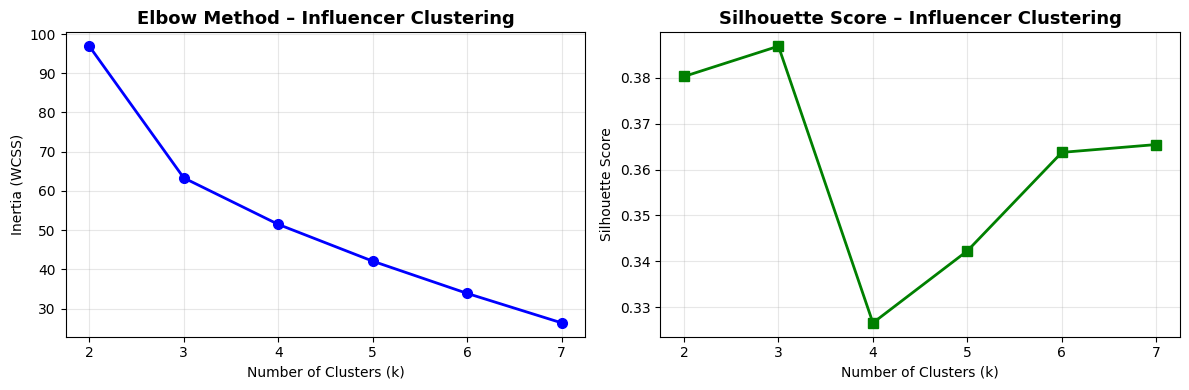

Best k by silhouette: 3  (score = 0.3869)
→ Using k = 3 (Low Priority / Mid Tier / High Value)
Saved: plot_09_influencer_elbow.png


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias_inf   = []
silhouettes_inf = []
K_RANGE_INF    = range(2, 8)

for k in K_RANGE_INF:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_inf_scaled)
    inertias_inf.append(km.inertia_)
    silhouettes_inf.append(silhouette_score(X_inf_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE_INF), inertias_inf, "bo-", linewidth=2, markersize=7)
ax1.set_title("Elbow Method – Influencer Clustering", fontsize=13, fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE_INF), silhouettes_inf, "gs-", linewidth=2, markersize=7)
ax2.set_title("Silhouette Score – Influencer Clustering", fontsize=13, fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot_09_influencer_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

best_k_inf = int(np.argmax(silhouettes_inf)) + 2   # offset because range starts at 2
print(f"Best k by silhouette: {best_k_inf}  (score = {max(silhouettes_inf):.4f})")
print("→ Using k = 3 (Low Priority / Mid Tier / High Value)")
print("Saved: plot_09_influencer_elbow.png")

## 8. Fit KMeans (k = 3) & Label Clusters

In [14]:
km_inf = KMeans(n_clusters=3, random_state=42, n_init=10)
inf["raw_cluster"] = km_inf.fit_predict(X_inf_scaled)

# Remap clusters so labels are deterministic:
# Sort by mean engagement_rate → 0 = Low Priority, 1 = Mid Tier, 2 = High Value
centers_eng = km_inf.cluster_centers_[:, 0]   # engagement_rate is feature index 0
sorted_idx   = np.argsort(centers_eng)         # ascending engagement → 0=Low
remap_inf    = {old: new for new, old in enumerate(sorted_idx)}
inf["inf_cluster"] = inf["raw_cluster"].map(remap_inf)

INF_CLUSTER_LABELS  = {0: "Low Priority", 1: "Mid Tier", 2: "High Value"}
INF_CLUSTER_COLORS  = {0: "#E74C3C",      1: "#F39C12",  2: "#27AE60"}
inf["cluster_label"] = inf["inf_cluster"].map(INF_CLUSTER_LABELS)

# Summary statistics per cluster
summary = inf.groupby("cluster_label")[
    ["engagement_rate", "followers", "hashtag_alignment_score",
     "post_frequency_per_week", "sponsored_post_ratio"]
].mean().round(3)

print("=== Cluster Summary (mean per feature) ===\n")
print(summary.to_string())
print()
print("=== Cluster Size ===")
print(inf["cluster_label"].value_counts().to_string())

=== Cluster Summary (mean per feature) ===

               engagement_rate    followers  hashtag_alignment_score  post_frequency_per_week  sponsored_post_ratio
cluster_label                                                                                                      
High Value               7.367     5560.000                    7.800                    5.600                 0.075
Low Priority             0.728  2125454.545                    5.273                    3.455                 0.675
Mid Tier                 2.430   108380.952                    7.667                    5.476                 0.287

=== Cluster Size ===
cluster_label
Mid Tier        21
Low Priority    11
High Value      10


## 9. Visualizations

### 9.1 – Engagement Rate vs Followers (Colored by Cluster)

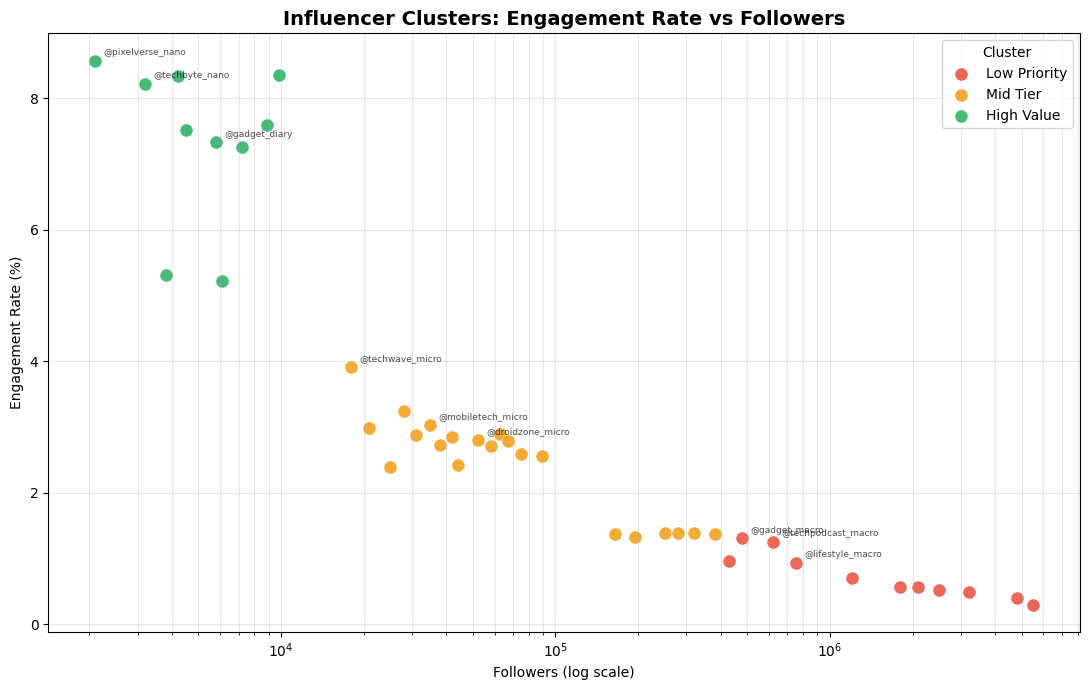

Saved: plot_10_influencer_scatter.png


In [15]:
fig, ax = plt.subplots(figsize=(11, 7))

for cluster_id, label in INF_CLUSTER_LABELS.items():
    mask = inf["inf_cluster"] == cluster_id
    ax.scatter(
        inf.loc[mask, "followers"],
        inf.loc[mask, "engagement_rate"],
        label=label,
        color=INF_CLUSTER_COLORS[cluster_id],
        s=90, alpha=0.85, edgecolors="white", linewidths=0.5,
    )
    # Annotate a few handles per cluster for readability
    for _, row in inf[mask].head(3).iterrows():
        ax.annotate(
            row["handle"],
            (row["followers"], row["engagement_rate"]),
            fontsize=6.5, alpha=0.7,
            xytext=(6, 4), textcoords="offset points",
        )

ax.set_xscale("log")
ax.set_title("Influencer Clusters: Engagement Rate vs Followers",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Followers (log scale)")
ax.set_ylabel("Engagement Rate (%)")
ax.legend(title="Cluster", fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("plot_10_influencer_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_10_influencer_scatter.png")

### 9.2 – Cluster Feature Comparison (Bar Chart)

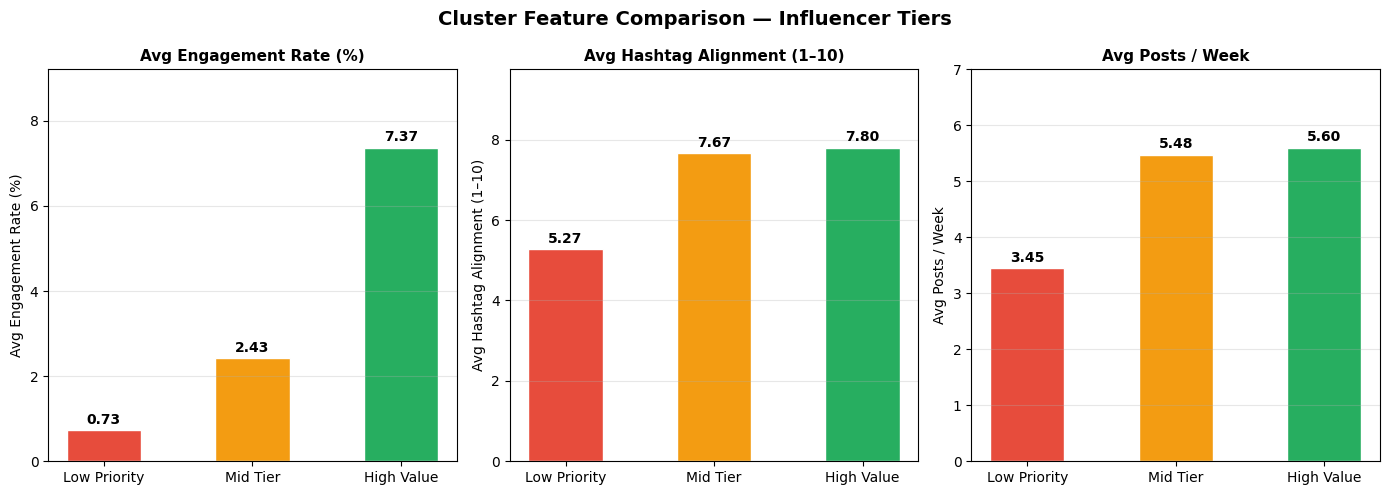

Saved: plot_11_influencer_feature_comparison.png


In [16]:
COMPARE_FEATS = {
    "engagement_rate"          : "Avg Engagement Rate (%)",
    "hashtag_alignment_score"  : "Avg Hashtag Alignment (1–10)",
    "post_frequency_per_week"  : "Avg Posts / Week",
}

cluster_order  = ["Low Priority", "Mid Tier", "High Value"]
bar_colors_ord = [INF_CLUSTER_COLORS[k] for k, v in INF_CLUSTER_LABELS.items()]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Cluster Feature Comparison — Influencer Tiers",
             fontsize=14, fontweight="bold")

for ax, (feat, feat_label) in zip(axes, COMPARE_FEATS.items()):
    vals = [inf[inf["cluster_label"] == c][feat].mean() for c in cluster_order]
    bars = ax.bar(cluster_order, vals, color=bar_colors_ord, edgecolor="white", width=0.5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

    ax.set_title(feat_label, fontsize=11, fontweight="bold")
    ax.set_ylabel(feat_label)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("plot_11_influencer_feature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_11_influencer_feature_comparison.png")

### 9.3 – Cluster Distribution by Follower Tier

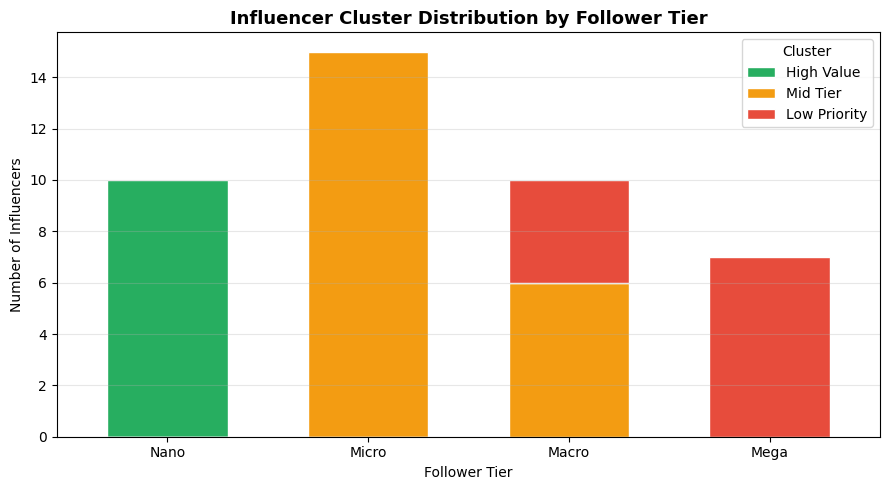

Saved: plot_12_influencer_cluster_by_tier.png


In [17]:
tier_order    = ["Nano", "Micro", "Macro", "Mega"]
cluster_order = ["High Value", "Mid Tier", "Low Priority"]
cluster_colors_stacked = ["#27AE60", "#F39C12", "#E74C3C"]

pivot = (
    inf.groupby(["tier", "cluster_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=tier_order)
    .reindex(columns=cluster_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=cluster_colors_stacked, edgecolor="white", width=0.6)

ax.set_title("Influencer Cluster Distribution by Follower Tier",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Follower Tier")
ax.set_ylabel("Number of Influencers")
ax.set_xticklabels(tier_order, rotation=0)
ax.legend(title="Cluster", loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_12_influencer_cluster_by_tier.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_12_influencer_cluster_by_tier.png")

## 10. Final Recommendation — Whom to Choose?

In [18]:
print("=" * 65)
print("  INFLUENCER SELECTION RECOMMENDATION (Unsupervised Clustering)")
print("=" * 65)

for cluster_id in [2, 1, 0]:   # High → Mid → Low
    label  = INF_CLUSTER_LABELS[cluster_id]
    subset = inf[inf["inf_cluster"] == cluster_id]
    print(f"\n▶  Cluster: {label}")
    print(f"   Count              : {len(subset)} influencers")
    print(f"   Follower range     : {subset['followers'].min():,} – {subset['followers'].max():,}")
    print(f"   Avg engagement rate: {subset['engagement_rate'].mean():.2f}%")
    print(f"   Avg hashtag align  : {subset['hashtag_alignment_score'].mean():.1f} / 10")
    print(f"   Avg posts/week     : {subset['post_frequency_per_week'].mean():.1f}")
    top3 = subset.nlargest(3, "engagement_rate")[["handle","followers","engagement_rate"]]
    print(f"   Top 3 by engagement:")
    for _, r in top3.iterrows():
        print(f"     {r['handle']:<30} followers={r['followers']:>8,}  ER={r['engagement_rate']:.2f}%")

print()
print("=" * 65)
print("  VERDICT: Choose influencers from the 'HIGH VALUE' cluster.")
print("  They deliver the highest engagement rates AND strong")
print("  hashtag alignment with tech brand campaigns, making")
print("  them the most cost-effective choice for organic reach.")
print("=" * 65)

# Save influencer cluster results
inf.to_csv("data/influencer_clustered.csv", index=False)
print("\nSaved: data/influencer_clustered.csv")

  INFLUENCER SELECTION RECOMMENDATION (Unsupervised Clustering)

▶  Cluster: High Value
   Count              : 10 influencers
   Follower range     : 2,100 – 9,800
   Avg engagement rate: 7.37%
   Avg hashtag align  : 7.8 / 10
   Avg posts/week     : 5.6
   Top 3 by engagement:
     @pixelverse_nano               followers=   2,100  ER=8.57%
     @coder_nano                    followers=   9,800  ER=8.35%
     @gadget_girl                   followers=   4,200  ER=8.33%

▶  Cluster: Mid Tier
   Count              : 21 influencers
   Follower range     : 18,000 – 380,000
   Avg engagement rate: 2.43%
   Avg hashtag align  : 7.7 / 10
   Avg posts/week     : 5.5
   Top 3 by engagement:
     @techwave_micro                followers=  18,000  ER=3.92%
     @applesphere_micro             followers=  28,000  ER=3.25%
     @mobiletech_micro              followers=  35,000  ER=3.03%

▶  Cluster: Low Priority
   Count              : 11 influencers
   Follower range     : 430,000 – 5,500,000
   A